In [1]:
import json
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [3]:
json_path = "../data/detection_2/train/_annotations.coco.json"

with open(json_path) as f:
    coco = json.load(f)
print(coco.keys())

dict_keys(['info', 'licenses', 'categories', 'images', 'annotations'])


In [4]:
category_map = {c["id"]:c["name"] for c in coco["categories"]} # mapping category
category_map

{0: '.dot', 1: 'Cardboard', 2: 'Glass', 3: 'Metal', 4: 'Paper', 5: 'Plastic'}

In [5]:
image_map = {img["id"]:img["file_name"] for img in coco["images"]} # mapping image id
image_map

{0: 'plastic134_jpg.rf.001bcbadfdd5a322471e4683ed26892d.jpg',
 1: 'paper563_jpg.rf.002466dbb740915a8c8db6d36cf711ee.jpg',
 2: 'glass269_jpg.rf.0041369e0dee098539a67371b9d865c6.jpg',
 3: 'glass302_jpg.rf.002fc301304add46dd594ee8aa71acd4.jpg',
 4: 'cardboard137_jpg.rf.004dc53ee8ae142639c0598a42d19c73.jpg',
 5: 'green-glass80_jpg.rf.0089fe8d4a5a1e5e46f05063631a5aa7.jpg',
 6: 'green-glass479_jpg.rf.00becad819c4f88a39b5a63fa966aced.jpg',
 7: 'cardboard180_jpg.rf.0036632368c6098d4628ec446e630ff9.jpg',
 8: 'white-glass185_jpg.rf.0099751d43f10fee503eee91a9fe67ad.jpg',
 9: 'plastic357_jpg.rf.00c0ec3f059a5815302ba834e83537b7.jpg',
 10: 'plastic342_jpg.rf.00837d781c46ae4dede7824ffd0d3e0f.jpg',
 11: 'paper116_jpg.rf.00cc950c49034873d10dc5a0ee4056ff.jpg',
 12: 'paper83_jpg.rf.00cb691eaf3fcc2e09603374467546aa.jpg',
 13: 'paper155_jpg.rf.006d05dd913d8668090a5930047badfa.jpg',
 14: 'Metal15_png.rf.00a32b46809431e9e097d43b459434fe.jpg',
 15: 'glass445_jpg.rf.0083c1651d0dc44e57fa69ae9eea886f.jpg',
 16: 

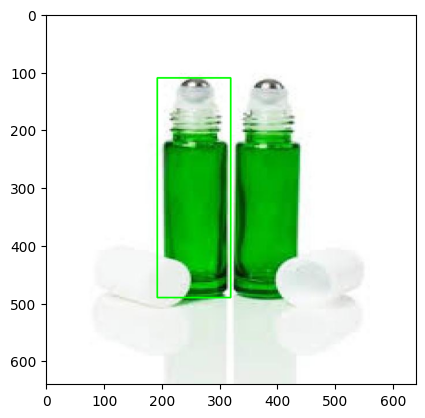

In [7]:
# test bbox
ann = coco["annotations"][10]
img_name = image_map[ann["image_id"]]
img = cv2.imread("../data/detection_2/train/"+img_name)

x, y, w, h = ann["bbox"]

cv2.rectangle(img, (int(x), int(y)), (int(x+w), int(y+h)), (0, 255, 0), 2)
# kiểm chứng bounding box đọc đúng tọa độ chưa
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.show()

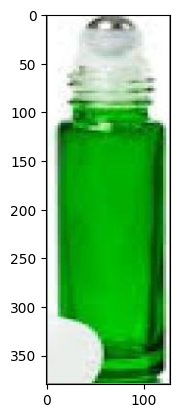

In [8]:
# crop object
crop = img[int(y):int(y+h), int(x):int(x+w)] # [y1:y2, x1:x2]

plt.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))

In [9]:
from src.data_pipeline import ClassificationDataset
from torch.utils.data import DataLoader

dataset = ClassificationDataset("../data/classification/")

loader = DataLoader(dataset, batch_size=8, shuffle=True)

imgs, labels = next(iter(loader))

print(imgs.shape) # kết quả "img.shape = [8, 3, 224, 224]" đã đúng chuẩn input CNN

ModuleNotFoundError: No module named 'src'